# 📦 Forecasting de Demanda — E-Commerce Brasileiro (Olist)
## Notebook 02 — Pré-processamento e Preparação para Modelagem

**Objetivo:** Limpar a série temporal gerada na EDA, tratar anomalias e preparar os dados no formato exigido pelo Prophet.

**Input:** `data/processed/serie_temporal_mensal.csv`  
**Output:** `data/processed/serie_modelagem.csv`

---
**Etapas:**
1. Inspecionar a série e identificar meses problemáticos
2. Remover meses de ramp-up (Out–Dez/2016)
3. Verificar integridade do último mês (Ago/2018)
4. Criar tabela de feriados/eventos (Black Friday)
5. Visualizar a série final
6. Exportar no formato Prophet (`ds`, `y`)

## 1. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
COR_AZUL    = '#2E75B6'
COR_LARANJA = '#C55A11'
COR_VERDE   = '#70AD47'
COR_CINZA   = '#BFBFBF'

print('✅ Bibliotecas carregadas')

✅ Bibliotecas carregadas


## 2. Carregamento da Série Temporal

In [2]:
serie = pd.read_csv('../data/processed/serie_temporal_mensal.csv')
serie['ds'] = pd.to_datetime(serie['ds'])
serie = serie.sort_values('ds').reset_index(drop=True)

print(f'Período bruto: {serie["ds"].min().strftime("%b/%Y")} → {serie["ds"].max().strftime("%b/%Y")}')
print(f'Total de meses: {len(serie)}')
print()
serie[['ds', 'qtd_pedidos', 'receita_total', 'ticket_medio']]

Período bruto: Sep/2016 → Aug/2018
Total de meses: 23



,ds,qtd_pedidos,receita_total,ticket_medio
0,2016-09-01,1,0.00,0.000000
1,2016-10-01,265,46566.71,175.723434
2,2016-12-01,1,19.62,19.620000
3,2017-01-01,750,127545.67,170.060893
4,2017-02-01,1653,271298.65,164.125015
5,2017-03-01,2546,414369.39,162.753099
6,2017-04-01,2303,390952.18,169.757785
7,2017-05-01,3546,567066.73,159.917296
8,2017-06-01,3135,490225.60,156.371802
9,2017-07-01,3872,566403.93,146.282007


## 3. Diagnóstico de Anomalias

Visualizamos a série bruta para identificar meses problemáticos antes da limpeza.

In [3]:
# Meses com volume anormalmente baixo (< 100 pedidos)
anomalos = serie[serie['qtd_pedidos'] < 100]
print('=== Meses com < 100 pedidos ===')
print(anomalos[['ds', 'qtd_pedidos']].to_string(index=False))

# Mês ausente
meses_esperados = pd.date_range(start=serie['ds'].min(), end=serie['ds'].max(), freq='MS')
meses_ausentes  = meses_esperados.difference(serie['ds'])
print(f'\n=== Meses ausentes na série ===')
for m in meses_ausentes:
    print(f'  {m.strftime("%b/%Y")}')

# Verificar integridade do último mês
print(f'\n=== Último mês ===')
ultimo = serie.iloc[-1]
print(f'  {ultimo["ds"].strftime("%b/%Y")}: {ultimo["qtd_pedidos"]:,} pedidos')
print(f'  Obs: dataset termina em 29/Ago/2018 — faltam 2 dias (~6% do mês). Volume mantido com nota.')

=== Meses com < 100 pedidos ===
        ds  qtd_pedidos
2016-09-01            1
2016-12-01            1

=== Meses ausentes na série ===
  Nov/2016

=== Último mês ===
  Aug/2018: 6,351 pedidos
  Obs: dataset termina em 29/Ago/2018 — faltam 2 dias (~6% do mês). Volume mantido com nota.


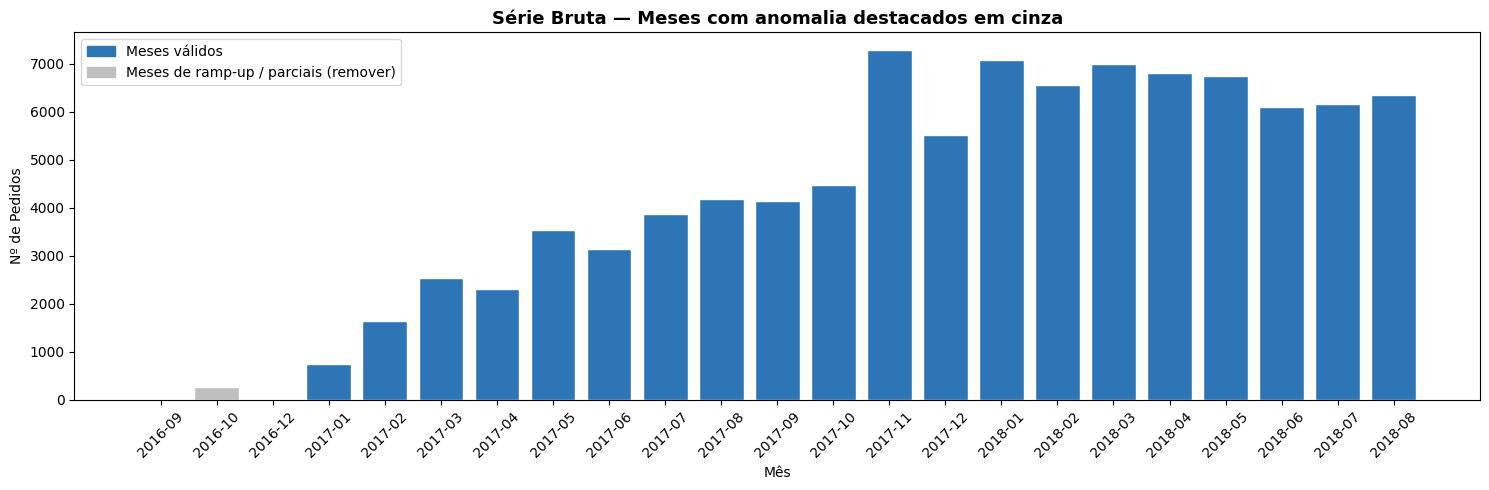

✅ Gráfico salvo


In [4]:
# Visualização da série bruta com marcação dos meses problemáticos
fig, ax = plt.subplots(figsize=(15, 5))

cores = [COR_CINZA if row['qtd_pedidos'] < 500 else COR_AZUL for _, row in serie.iterrows()]
ax.bar(serie['ds'].dt.strftime('%Y-%m'), serie['qtd_pedidos'], color=cores, edgecolor='white')

ax.set_title('Série Bruta — Meses com anomalia destacados em cinza', fontsize=13, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Nº de Pedidos')
ax.tick_params(axis='x', rotation=45)

patch_ok     = mpatches.Patch(color=COR_AZUL,  label='Meses válidos')
patch_anomal = mpatches.Patch(color=COR_CINZA, label='Meses de ramp-up / parciais (remover)')
ax.legend(handles=[patch_ok, patch_anomal])

plt.tight_layout()
plt.savefig('../data/processed/serie_bruta_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo')

## 4. Limpeza — Removendo Meses de Ramp-up

**Critério:** Remover Set/2016, Out/2016 e Dez/2016 pois representam o período de operação
inicial da Olist, com volume muito abaixo do padrão estabelecido. Nov/2016 já estava ausente.

A série limpa começa em **Janeiro/2017**, com 20 meses de dados consistentes.

In [5]:
# Filtrar série a partir de Jan/2017
serie_limpa = serie[serie['ds'] >= '2017-01-01'].copy().reset_index(drop=True)

print(f'Série bruta : {len(serie):>3} meses')
print(f'Série limpa : {len(serie_limpa):>3} meses')
print(f'Período     : {serie_limpa["ds"].min().strftime("%b/%Y")} → {serie_limpa["ds"].max().strftime("%b/%Y")}')
print(f'Min pedidos : {serie_limpa["qtd_pedidos"].min():,} ({serie_limpa.loc[serie_limpa["qtd_pedidos"].idxmin(), "ds"].strftime("%b/%Y")})')
print(f'Max pedidos : {serie_limpa["qtd_pedidos"].max():,} ({serie_limpa.loc[serie_limpa["qtd_pedidos"].idxmax(), "ds"].strftime("%b/%Y")})')

Série bruta :  23 meses
Série limpa :  20 meses
Período     : Jan/2017 → Aug/2018
Min pedidos : 750 (Jan/2017)
Max pedidos : 7,289 (Nov/2017)


## 5. Criação da Tabela de Feriados/Eventos

O Prophet aceita uma tabela de `holidays` para modelar eventos que causam picos ou quedas pontuais.

Incluímos a **Black Friday** (novembro) como evento — responsável pelo pico de +32% em Nov/2017.

In [6]:
# Prophet espera: colunas 'holiday', 'ds', e opcionalmente 'lower_window', 'upper_window'
# Para série mensal, ds deve coincidir com o primeiro dia do mês
feriados = pd.DataFrame({
    'holiday'      : 'black_friday',
    'ds'           : pd.to_datetime(['2017-11-01', '2018-11-01']),
    'lower_window' : 0,
    'upper_window' : 0,
})

print('Tabela de feriados/eventos:')
print(feriados.to_string(index=False))

Tabela de feriados/eventos:
     holiday         ds  lower_window  upper_window
black_friday 2017-11-01             0             0
black_friday 2018-11-01             0             0


## 6. Visualização da Série Final

In [7]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=serie_limpa['ds'],
    y=serie_limpa['qtd_pedidos'],
    mode='lines+markers',
    name='Pedidos/mês',
    line=dict(color=COR_AZUL, width=2.5),
    marker=dict(size=7)
))

# Marcar Black Friday
bf = serie_limpa[serie_limpa['ds'] == '2017-11-01']
fig.add_trace(go.Scatter(
    x=bf['ds'],
    y=bf['qtd_pedidos'],
    mode='markers',
    name='Black Friday',
    marker=dict(color=COR_LARANJA, size=14, symbol='star')
))

# Anotação do último mês
fig.add_annotation(
    x=serie_limpa['ds'].iloc[-1],
    y=serie_limpa['qtd_pedidos'].iloc[-1],
    text='Ago/2018<br>(dataset parcial<br>até dia 29)',
    showarrow=True, arrowhead=2,
    ax=40, ay=-40,
    font=dict(size=11)
)

fig.update_layout(
    title='📈 Série Temporal Limpa — Pedidos Mensais (Jan/2017–Ago/2018)',
    xaxis_title='Mês',
    yaxis_title='Nº de Pedidos',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

## 7. Exportação

Exportamos dois arquivos:
- `serie_modelagem.csv` — série limpa no formato Prophet (`ds`, `y`) + colunas auxiliares
- `feriados.csv` — tabela de eventos para o Prophet

In [8]:
# Formato Prophet: coluna alvo renomeada para 'y'
serie_export = serie_limpa[['ds', 'qtd_pedidos', 'receita_total', 'ticket_medio']].copy()
serie_export = serie_export.rename(columns={'qtd_pedidos': 'y'})

serie_export.to_csv('../data/processed/serie_modelagem.csv', index=False)
feriados.to_csv('../data/processed/feriados.csv', index=False)

print(f'✅ serie_modelagem.csv exportada: {len(serie_export)} meses')
print(f'✅ feriados.csv exportado: {len(feriados)} eventos')
print()
print('Primeiras linhas da série de modelagem:')
serie_export.head()

✅ serie_modelagem.csv exportada: 20 meses
✅ feriados.csv exportado: 2 eventos

Primeiras linhas da série de modelagem:


,ds,y,receita_total,ticket_medio
0,2017-01-01,750,127545.67,170.060893
1,2017-02-01,1653,271298.65,164.125015
2,2017-03-01,2546,414369.39,162.753099
3,2017-04-01,2303,390952.18,169.757785
4,2017-05-01,3546,567066.73,159.917296


## 8. Resumo do Pré-processamento

| Etapa | Decisão |
|---|---|
| Meses removidos | Set, Out e Dez/2016 — ramp-up inicial da Olist (< 300 pedidos) |
| Nov/2016 | Ausente na série bruta — descartado automaticamente |
| Ago/2018 | Mantido — dataset vai até dia 29 (~94% do mês), impacto marginal |
| Série final | 20 meses: Jan/2017 → Ago/2018 |
| Evento modelado | Black Friday (Nov/2017 e Nov/2018) via tabela de holidays do Prophet |
| Coluna alvo (`y`) | `qtd_pedidos` — volume de pedidos entregues por mês |

---
**Próximo passo:** `03_modeling.ipynb` — ajuste do Prophet, validação cruzada temporal e previsão 6 meses.